In [1]:
# Stage 1: Import Libraries
# Importing libraries for data analysis, visualization, machine learning, and evaluation.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Stage 2: Load Dataset
# Loading the diabetes dataset.

In [4]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [5]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
df.shape

(100000, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [8]:
# Stage 3: Data Understanding
# Understanding the distribution of diabetic and non-diabetic patients.

In [9]:
df['diabetes'].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

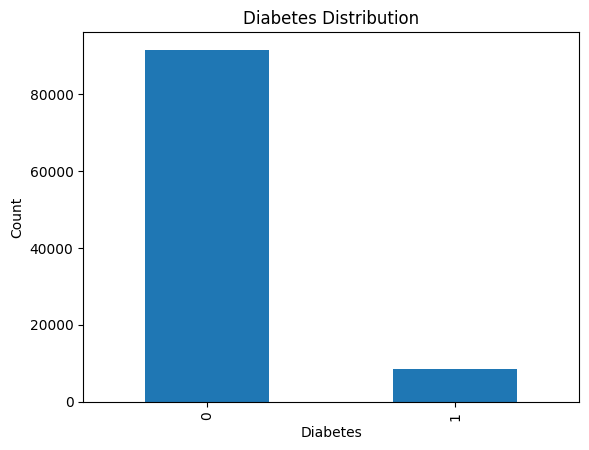

In [10]:
df['diabetes'].value_counts().plot(kind='bar')

plt.title("Diabetes Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")

plt.show()

In [11]:
# Stage 4: Data Cleaning
# Checking for missing values and duplicate records.

In [12]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(3854)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df['diabetes'].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

In [16]:
# Stage 5: Convert Categorical Variables
# Converting text columns into numerical values.
# Machine learning models cannot understand text data directly.

In [17]:
le_gender = LabelEncoder()

df['gender'] = le_gender.fit_transform(
    df['gender']
)

In [18]:
le_smoking = LabelEncoder()

df['smoking_history'] = le_smoking.fit_transform(
    df['smoking_history']
)

In [19]:
# Stage 6: Feature Selection
# Separating input features and target variable.

In [20]:
X = df.drop(
    'diabetes',
    axis=1
)

y = df['diabetes']

In [21]:
# Stage 7: Train-Test Split
# Splitting the dataset into training and testing sets.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
# Stage 8: Linear Regression
# Training a Linear Regression model.

In [24]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

pred_lr = (pred_lr > 0.5).astype(int)

accuracy_lr = accuracy_score(
    y_test,
    pred_lr
)

print("Accuracy:", accuracy_lr)

Accuracy: 0.9374934997399896


In [25]:
# Stage 9: KNN Classifier
# Training a KNN classifier.

In [26]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(
    y_test,
    pred_knn
)

print("Accuracy:", accuracy_knn)

Accuracy: 0.9515340613624546


In [27]:
# Stage 10: Decision Tree Classifier
# Training a Decision Tree classifier.

In [28]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(
    y_test,
    pred_dt
)

print("Accuracy:", accuracy_dt)

Accuracy: 0.9473738949557983


In [29]:
# Stage 11: Random Forest Classifier
# Training a Random Forest classifier.

In [30]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(
    y_test,
    pred_rf
)

print("Accuracy:", accuracy_rf)

Accuracy: 0.9686427457098284


In [31]:
# Stage 12: AdaBoost Classifier
# Training an AdaBoost classifier.

In [32]:
ab = AdaBoostClassifier(
    random_state=42
)

ab.fit(X_train, y_train)

pred_ab = ab.predict(X_test)

accuracy_ab = accuracy_score(
    y_test,
    pred_ab
)

print("Accuracy:", accuracy_ab)

Accuracy: 0.970566822672907


In [33]:
# Stage 13: Model Comparison
# Comparing all model accuracies.

In [34]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'AdaBoost'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf,
        accuracy_ab
    ]
})

results

,Model,Accuracy
0,Linear Regression,0.937493
1,KNN,0.951534
2,Decision Tree,0.947374
3,Random Forest,0.968643
4,AdaBoost,0.970567


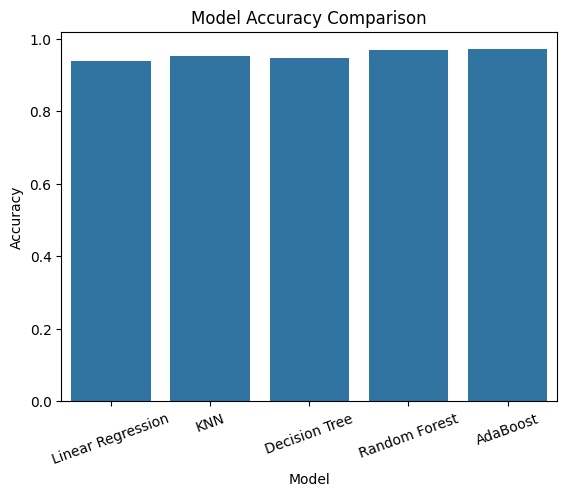

In [35]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.xticks(rotation=20)

plt.title("Model Accuracy Comparison")

plt.show()

In [36]:
# Stage 14: Best Model Evaluation
# Evaluating the best-performing model using a confusion matrix and classification report.

In [37]:
print(
    confusion_matrix(
        y_test,
        pred_ab
    )
)

[[17509     0]
 [  566  1155]]


In [38]:
print(
    classification_report(
        y_test,
        pred_ab
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       1.00      0.67      0.80      1721

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



In [39]:
# Final Findings
# 1. The dataset contained 96,146 patient records, including 87,664 non-diabetic individuals and 8,482 diabetic individuals.
# 2. Linear Regression achieved an accuracy of 93.75% after converting predictions into classification labels.
# 3. K-Nearest Neighbors (KNN) achieved an accuracy of 95.15%, showing strong classification performance.
# 4. Decision Tree Classifier achieved an accuracy of 94.74%.
# 5. Random Forest Classifier achieved an accuracy of 96.86%, performing better than most of the models tested.
# 6. AdaBoost Classifier achieved the highest accuracy of 97.06%, making it the best-performing model in this analysis.
# 7. The confusion matrix showed that the AdaBoost model correctly classified the majority of patients, with very few misclassifications.
# 8. The classification report showed high precision, recall, and F1-scores, indicating reliable diabetes prediction performance.

In [40]:
# Conclusion
# In this project, I developed a diabetes prediction model using machine learning techniques. Linear Regression, KNN, Decision Tree, Random Forest, 
# and AdaBoost algorithms were trained and evaluated using patient health data such as age, BMI, HbA1c level, blood glucose level, and medical history. 
# Among all models, AdaBoost achieved the highest accuracy of 97.06%, demonstrating strong performance in predicting diabetes. 
# The results highlight the effectiveness of machine learning in supporting early disease detection and healthcare decision-making.